# EDA Final — Heart Disease Dataset

**Kelompok:** larplarplarpsahur — 5054251016 / 5054251021 / 5054251048

**Dataset:** `heart_disease_dataset.csv` (1025 baris × 14 kolom, gabungan gaya UCI Heart Disease)

**Tujuan EDA:**
1. Memahami struktur, kualitas, dan distribusi data.
2. Mengidentifikasi hubungan tiap fitur terhadap `target` (0 = tidak sakit, 1 = sakit).
3. Menemukan anomali/keterbatasan data untuk dibahas di makalah dan sebagai bekal pemodelan.

> Catatan metodologi: baseline memakai 1025 baris mentah. Notebook final ini **menangani duplikat terlebih dahulu** 
(723 baris duplikat, 70,5%), lalu analisis utama memakai **data bersih (302 baris unik)** agar statistik tidak bias.

## Alur Analisis

1. Setup & load data
2. Kamus data
3. Overview (shape, head, info, describe)
4. Kualitas data (missing, duplikat → deduplikasi)
5. Distribusi target & fitur kategorik
6. Distribusi fitur numerik (histogram, skewness, outlier IQR)
7. Hubungan bivariat (korelasi, boxplot, countplot, crosstab, scatter, pairplot)
8. Ringkasan insight & rekomendasi

## 1. Setup Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", None)

## 2. Load Data (lokal, reproducible)

Memakai file lokal agar tidak bergantung pada URL GitHub saat sidang/demo.

In [2]:
df_raw = pd.read_csv("heart_disease_dataset.csv")
print("Shape mentah:", df_raw.shape)
df_raw.head()

Shape mentah: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. Kamus Data

| Kolom | Makna | Tipe / Nilai |
|---|---|---|
| `age` | Umur (tahun) | numerik 29–77 |
| `sex` | Jenis kelamin | 0 = wanita, 1 = pria |
| `cp` | Tipe nyeri dada | 0 = typical angina, 1 = atypical angina, 2 = non-anginal, 3 = asymptomatic |
| `trestbps` | Tekanan darah istirahat (mmHg) | numerik 94–200 |
| `chol` | Kolesterol serum (mg/dl) | numerik 126–564 |
| `fbs` | Gula darah puasa > 120 mg/dl | 0 = tidak, 1 = ya |
| `restecg` | Hasil EKG istirahat | 0 = normal, 1 = abnormalitas ST-T, 2 = hipertrofi ventrikel |
| `thalach` | Detak jantung maksimum | numerik 71–202 |
| `exang` | Angina akibat olahraga | 0 = tidak, 1 = ya |
| `oldpeak` | Depresi ST (oldpeak) | numerik 0–6,2 |
| `slope` | Kemiringan segmen ST | 0 = downsloping, 1 = flat, 2 = upsloping |
| `ca` | Jumlah pembuluh terwarnai fluoroskopi | 0–4 |
| `thal` | Status thalassemia | 0 = null, 1 = fixed defect, 2 = normal, 3 = reversible defect |
| `target` | Diagnosis | 0 = tidak sakit, 1 = sakit |

## 4. Overview Data Mentah

In [3]:
print("Shape:", df_raw.shape)
display(df_raw.head())
df_raw.info()
display(df_raw.describe().round(2))

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


## 5. Kualitas Data: Missing Value & Duplikat

**Temuan kunci:** tidak ada missing value, tetapi duplikat sangat besar (~70%). 
Ini khas dataset Heart Disease gabungan (Cleveland + Hungarian + Swiss + Long Beach + Statlog) 
yang digabung tanpa deduplikasi. Jika tidak ditangani, frekuensi & korelasi menjadi bias.

In [4]:
print("=== Missing value per kolom ===")
display(df_raw.isnull().sum())

n_dup = df_raw.duplicated().sum()
print(f"Duplikat: {n_dup} dari {len(df_raw)} baris ({n_dup/len(df_raw)*100:.1f}%)")
print(f"Baris unik: {len(df_raw.drop_duplicates())}")

# Keputusan: analisis utama memakai data bersih
df = df_raw.drop_duplicates().reset_index(drop=True)
print("Shape bersih:", df.shape)
display(df.groupby("target").size().rename({0: "Sehat (0)", 1: "Sakit (1)"}))

=== Missing value per kolom ===


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplikat: 723 dari 1025 baris (70.5%)
Baris unik: 302
Shape bersih: (302, 14)


target
Sehat (0)    138
Sakit (1)    164
dtype: int64

## 6. Distribusi Target & Fitur Kategorik (data bersih, n=302)

Target relatif seimbang sehingga tidak ada masalah class-imbalance berat untuk klasifikasi.

sex
0     96
1    206

cp
0    143
1     50
2     86
3     23

fbs
0    257
1     45

restecg
0    147
1    151
2      4

exang
0    203
1     99

slope
0     21
1    140
2    141

ca
0    175
1     65
2     38
3     20
4      4

thal
0      2
1     18
2    165
3    117

target
0    138
1    164



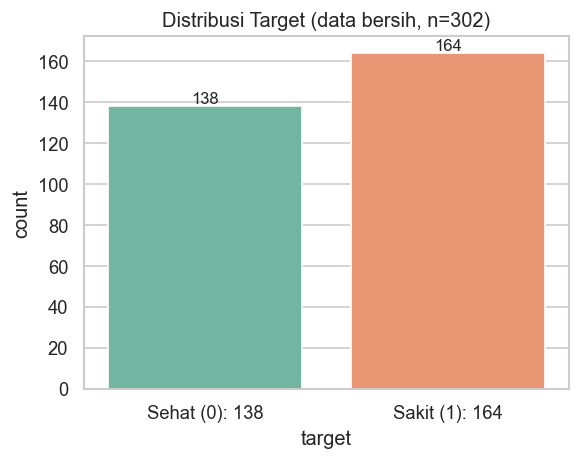

In [5]:
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]
for col in cat_cols:
    print(df[col].value_counts().sort_index().to_string())
    print()

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="target", data=df, hue="target", palette="Set2", legend=False, ax=ax)
ax.set_title("Distribusi Target (data bersih, n=302)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Sehat (0): 138", "Sakit (1): 164"])
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("fig_distribusi_target.png", dpi=300)
plt.show()

## 7. Distribusi Fitur Numerik: Skewness & Outlier

`chol` dan `oldpeak` menjulur kanan (right-skew); `thalach` menjulur kiri. 
Outlier IQR kecil (<3%) sehingga masih wajar secara klinis — tidak perlu dibuang, cukup dicatat.

=== Skewness (data bersih) ===
age        -0.204
trestbps    0.717
chol        1.147
thalach    -0.533
oldpeak     1.266


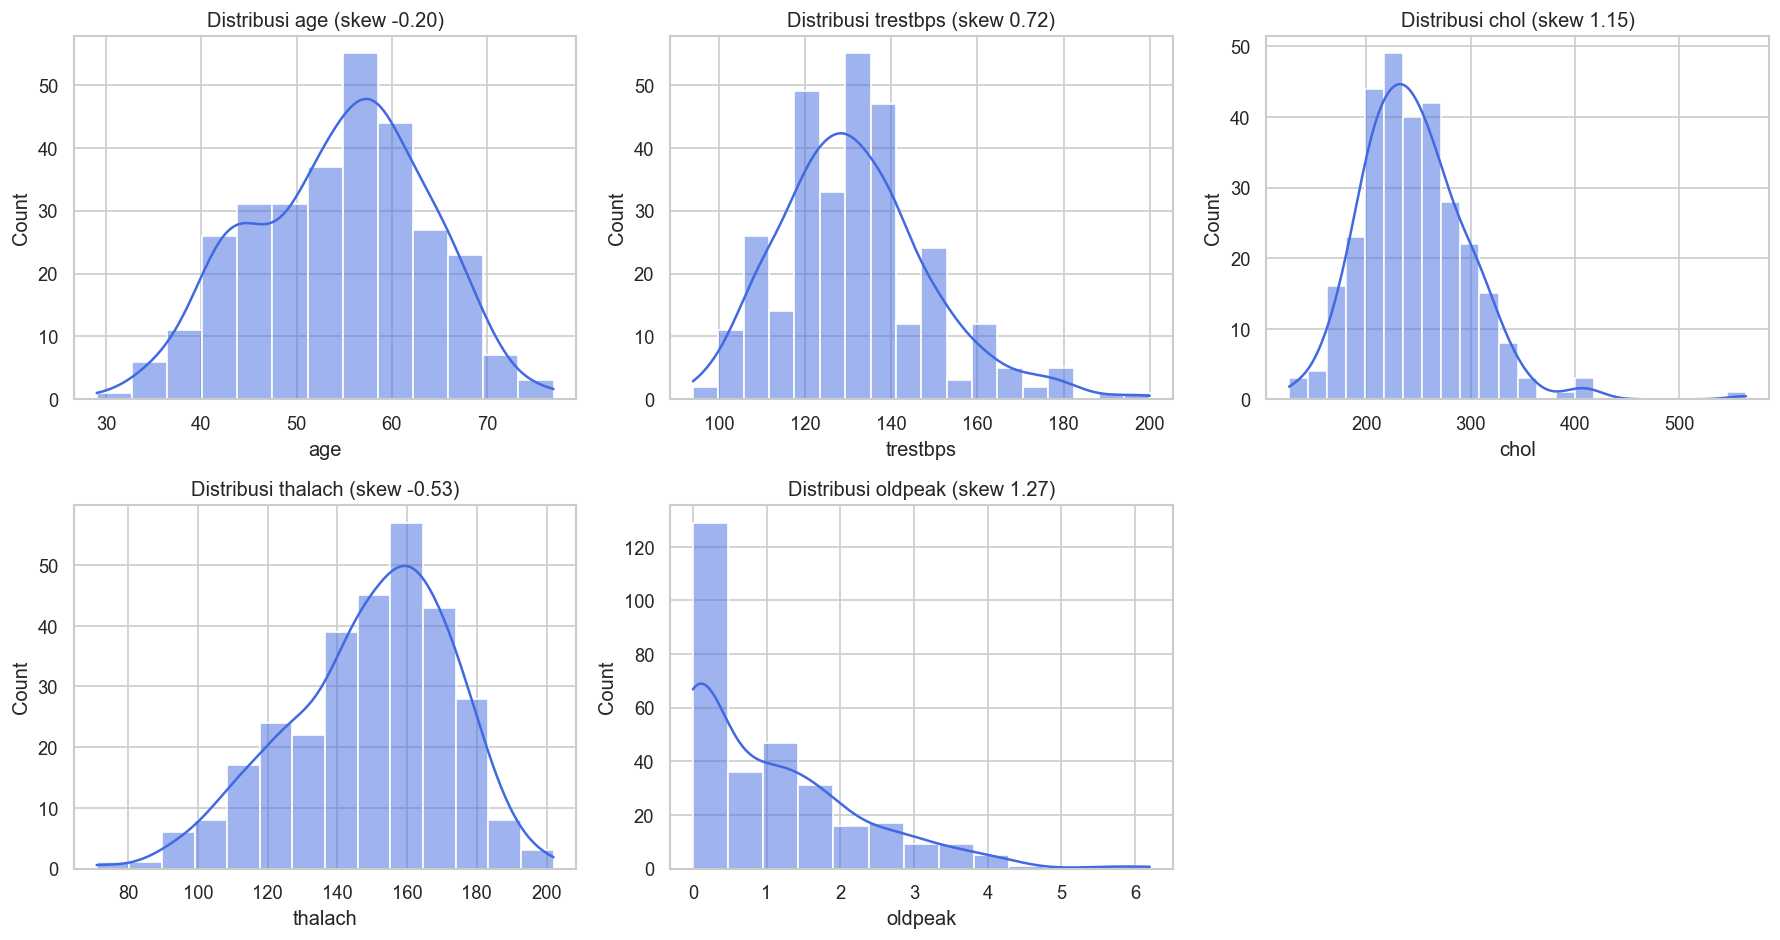

,Fitur,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persen (%)
0,age,48.00,61.00,13.00,28.500,80.500,0,0.00
1,trestbps,120.00,140.00,20.00,90.000,170.000,9,2.98
2,chol,211.00,274.75,63.75,115.375,370.375,5,1.66
3,thalach,133.25,166.00,32.75,84.125,215.125,1,0.33
4,oldpeak,0.00,1.60,1.60,-2.400,4.000,5,1.66


In [6]:
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
print("=== Skewness (data bersih) ===")
print(df[num_cols].skew().round(3).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color="royalblue")
    axes[i].set_title(f"Distribusi {col} (skew {df[col].skew():.2f})")
fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig("fig_distribusi_numerik.png", dpi=300)
plt.show()

# Tabel outlier IQR
rows = []
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    rows.append([col, q1, q3, iqr, lo, hi, n_out, round(n_out/len(df)*100, 2)])
df_outlier = pd.DataFrame(rows, columns=["Fitur", "Q1", "Q3", "IQR", "Batas Bawah", "Batas Atas", "Jumlah Outlier", "Persen (%)"])
display(df_outlier)

## 8. Hubungan Antar Fitur & terhadap Target

### 8.1 Matriks korelasi Pearson

target      1.000
cp          0.432
thalach     0.420
slope       0.344
restecg     0.135
fbs        -0.027
chol       -0.081
trestbps   -0.146
age        -0.221
sex        -0.284
thal       -0.343
ca         -0.409
oldpeak    -0.429
exang      -0.436
Name: korelasi vs target, dtype: float64

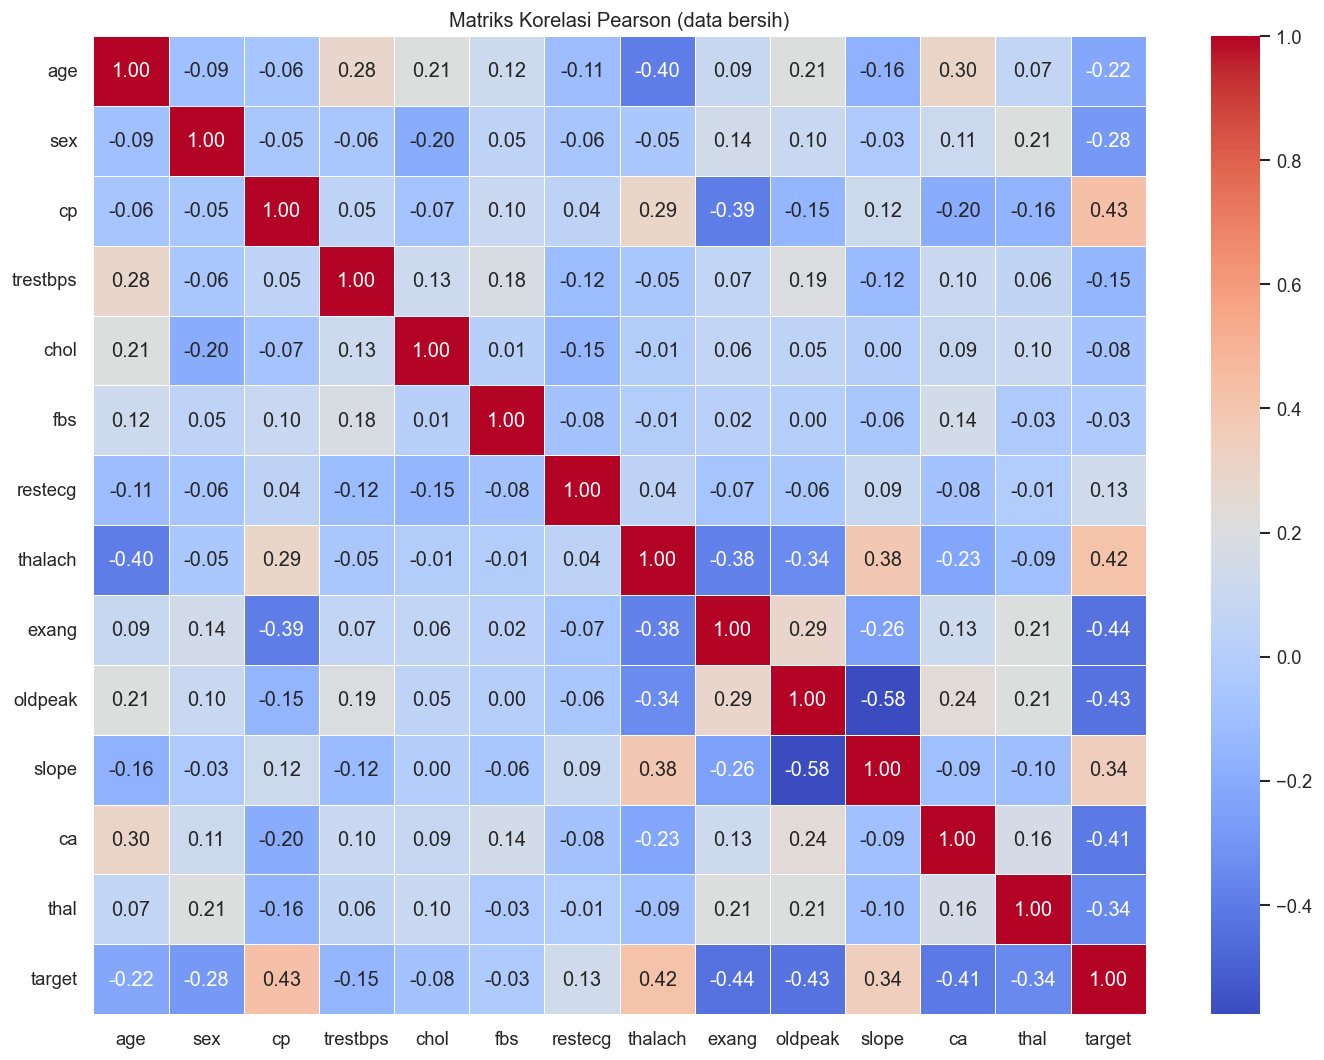

In [7]:
corr = df.corr(numeric_only=True)
display(corr["target"].sort_values(ascending=False).round(3).rename("korelasi vs target"))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matriks Korelasi Pearson (data bersih)")
plt.tight_layout()
plt.savefig("fig_heatmap_korelasi.png", dpi=300)
plt.show()

### 8.2 Peringkat relevansi fitur (absolute correlation)

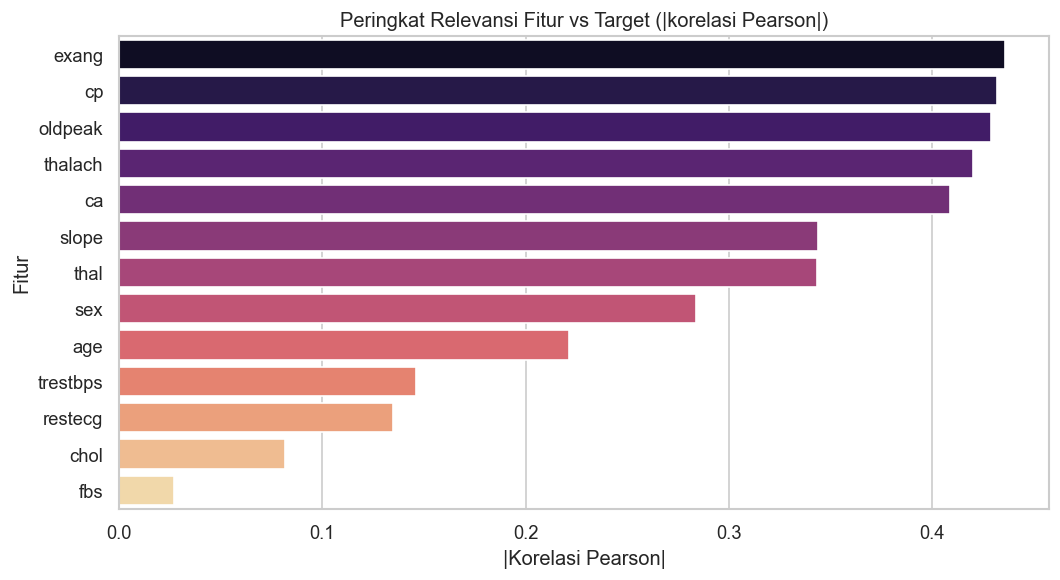

In [8]:
target_corr = df.corr(numeric_only=True)["target"].drop("target").abs().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, palette="magma", legend=False)
plt.title("Peringkat Relevansi Fitur vs Target (|korelasi Pearson|)")
plt.xlabel("|Korelasi Pearson|")
plt.ylabel("Fitur")
plt.tight_layout()
plt.savefig("fig_ranking_fitur.png", dpi=300)
plt.show()

### 8.3 Perbandingan distribusi thalach & oldpeak per target

Pasien sakit cenderung punya `thalach` lebih tinggi dan `oldpeak` lebih rendah — 
pola yang berlawanan dengan literatur klinis umum dan layak dibahas sebagai keterbatasan/anomali label data.

         age  thalach  oldpeak  trestbps   chol
target                                         
0       56.6    139.1      1.6     134.4  251.1
1       52.6    158.4      0.6     129.2  242.6


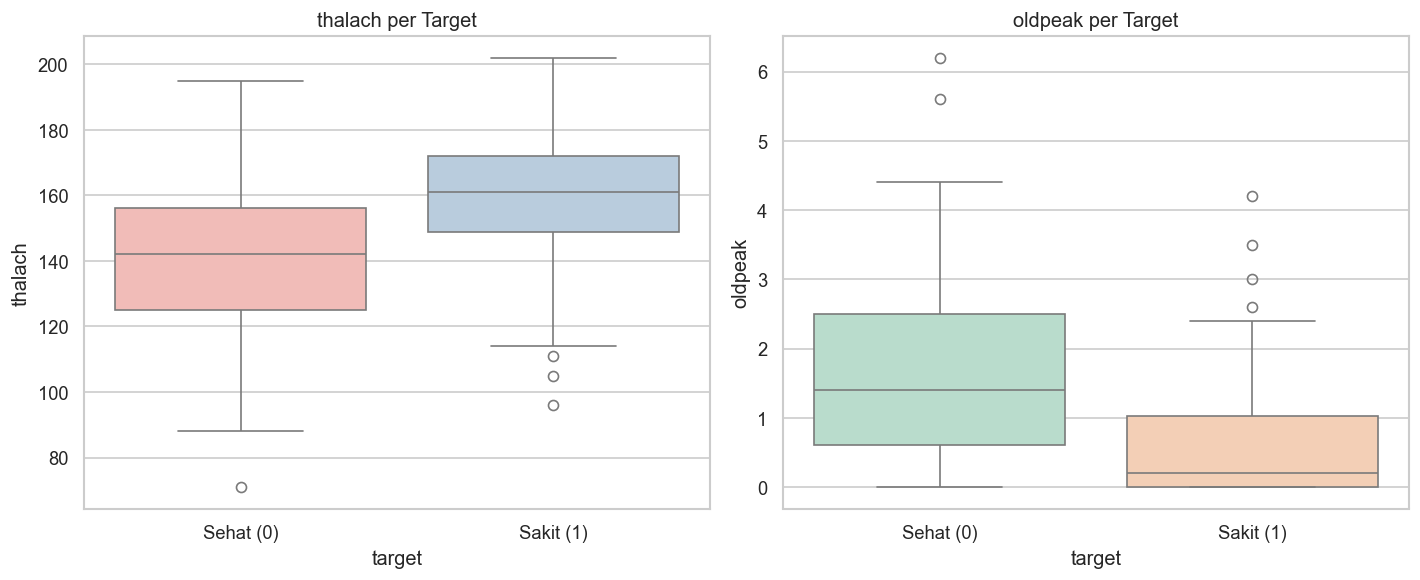

In [9]:
print(df.groupby("target")[["age", "thalach", "oldpeak", "trestbps", "chol"]].mean().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(ax=axes[0], data=df, x="target", y="thalach", hue="target", palette="Pastel1", legend=False)
axes[0].set_title("thalach per Target")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Sehat (0)", "Sakit (1)"])
sns.boxplot(ax=axes[1], data=df, x="target", y="oldpeak", hue="target", palette="Pastel2", legend=False)
axes[1].set_title("oldpeak per Target")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Sehat (0)", "Sakit (1)"])
plt.tight_layout()
plt.savefig("fig_boxplot_thalach_oldpeak.png", dpi=300)
plt.show()

### 8.4 Fitur kategorik vs target (sex, cp, exang)

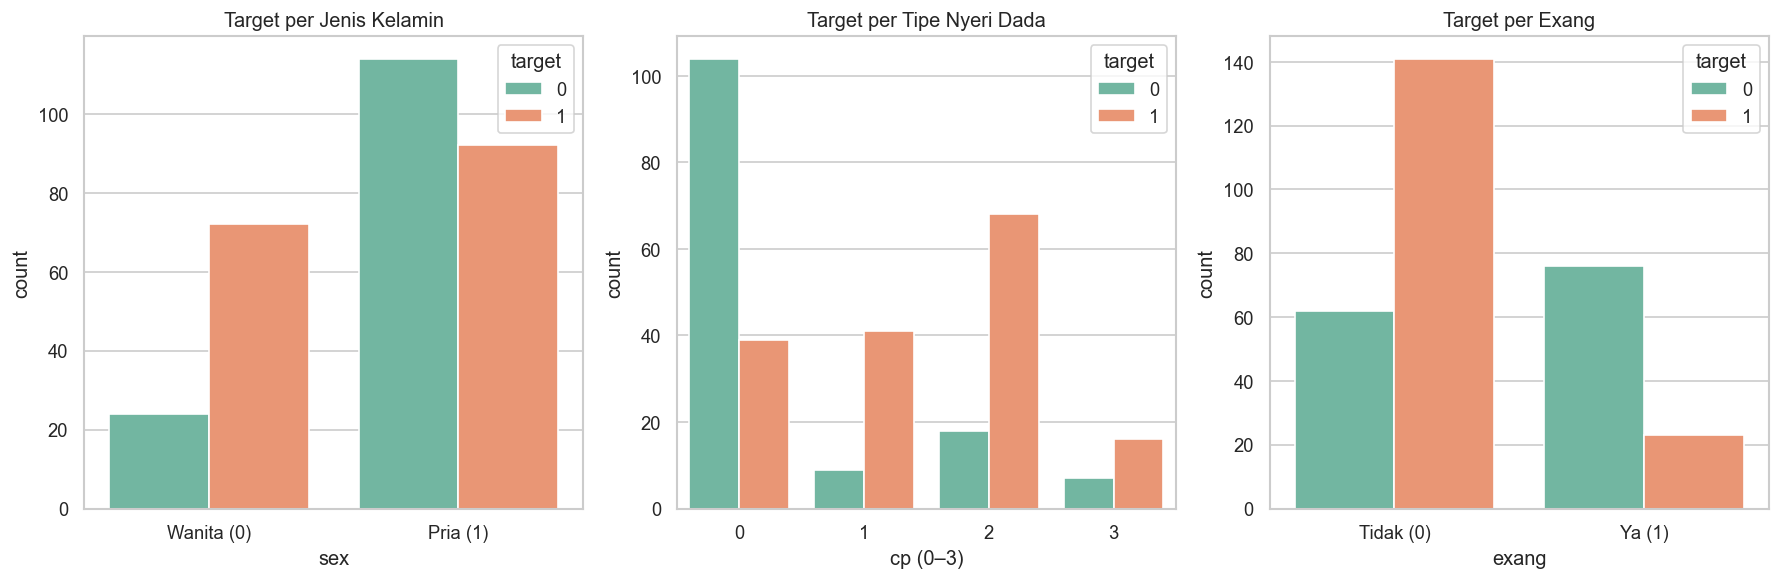

--- cp vs target (%) ---
target     0     1
cp                
0       72.7  27.3
1       18.0  82.0
2       20.9  79.1
3       30.4  69.6

--- sex vs target (%) ---
target     0     1
sex               
0       25.0  75.0
1       55.3  44.7

--- exang vs target (%) ---
target     0     1
exang             
0       30.5  69.5
1       76.8  23.2

--- ca vs target (%) ---
target     0     1
ca                
0       25.7  74.3
1       67.7  32.3
2       81.6  18.4
3       85.0  15.0
4       25.0  75.0

--- thal vs target (%) ---
target     0     1
thal              
0       50.0  50.0
1       66.7  33.3
2       21.8  78.2
3       76.1  23.9



In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(ax=axes[0], data=df, x="sex", hue="target", palette="Set2")
axes[0].set_title("Target per Jenis Kelamin")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Wanita (0)", "Pria (1)"])
sns.countplot(ax=axes[1], data=df, x="cp", hue="target", palette="Set2")
axes[1].set_title("Target per Tipe Nyeri Dada")
axes[1].set_xlabel("cp (0–3)")
sns.countplot(ax=axes[2], data=df, x="exang", hue="target", palette="Set2")
axes[2].set_title("Target per Exang")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["Tidak (0)", "Ya (1)"])
plt.tight_layout()
plt.savefig("fig_countplot_kategorik.png", dpi=300)
plt.show()

for col in ["cp", "sex", "exang", "ca", "thal"]:
    print(f"--- {col} vs target (%) ---")
    print(((pd.crosstab(df[col], df["target"], normalize="index"))*100).round(1).to_string())
    print()

### 8.5 Heatmap persentase diagnosis (siap jadi tabel/gambar makalah)

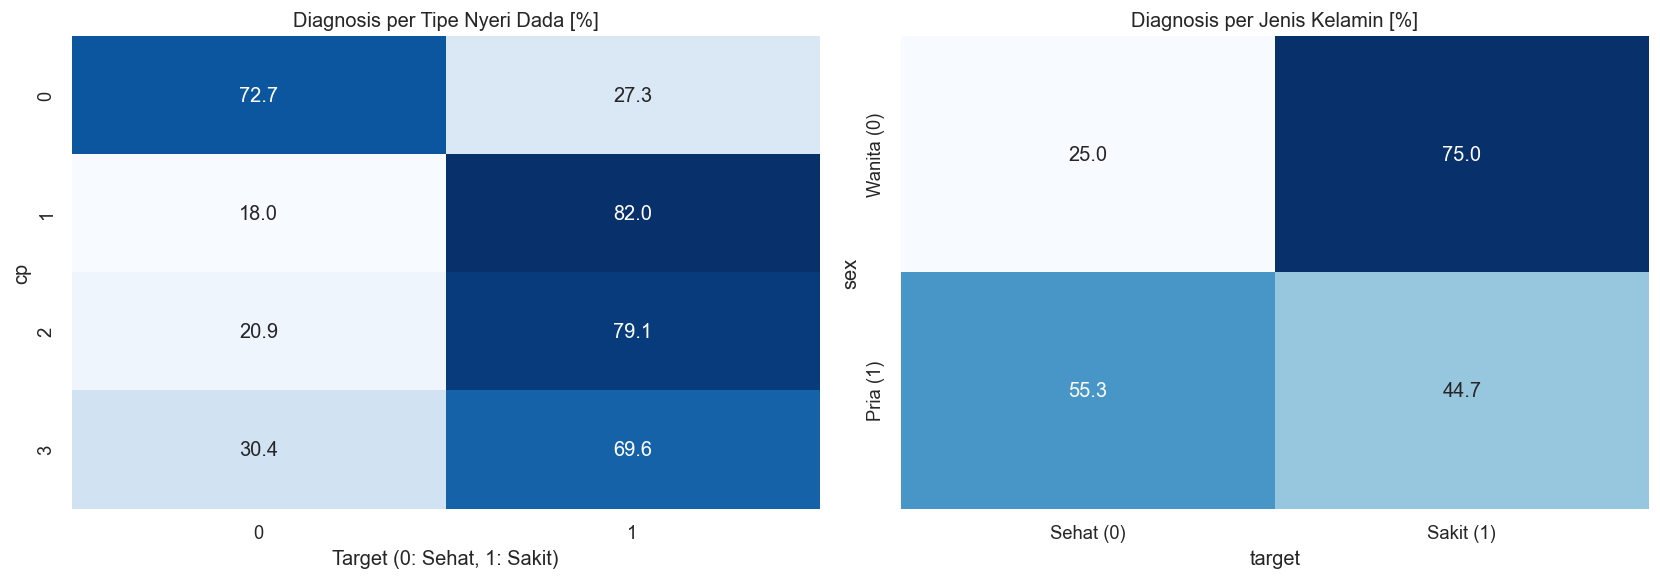

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ct_cp = pd.crosstab(df["cp"], df["target"], normalize="index") * 100
sns.heatmap(ct_cp, annot=True, fmt=".1f", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Diagnosis per Tipe Nyeri Dada [%]")
axes[0].set_xlabel("Target (0: Sehat, 1: Sakit)")
ct_sex = pd.crosstab(df["sex"], df["target"], normalize="index") * 100
sns.heatmap(ct_sex, annot=True, fmt=".1f", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Diagnosis per Jenis Kelamin [%]")
axes[1].set_xticklabels(["Sehat (0)", "Sakit (1)"])
axes[1].set_yticklabels(["Wanita (0)", "Pria (1)"])
plt.tight_layout()
plt.savefig("fig_crosstab_cp_sex.png", dpi=300)
plt.show()

### 8.6 Interaksi usia–thalach–cp dan pairplot numerik

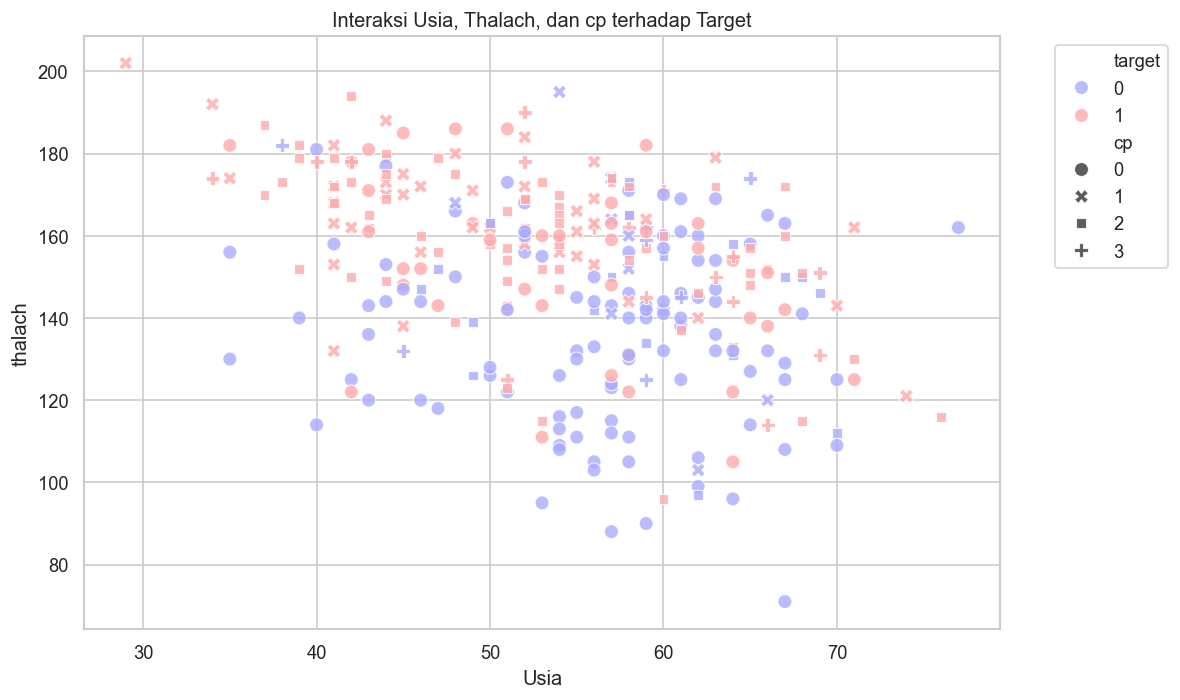

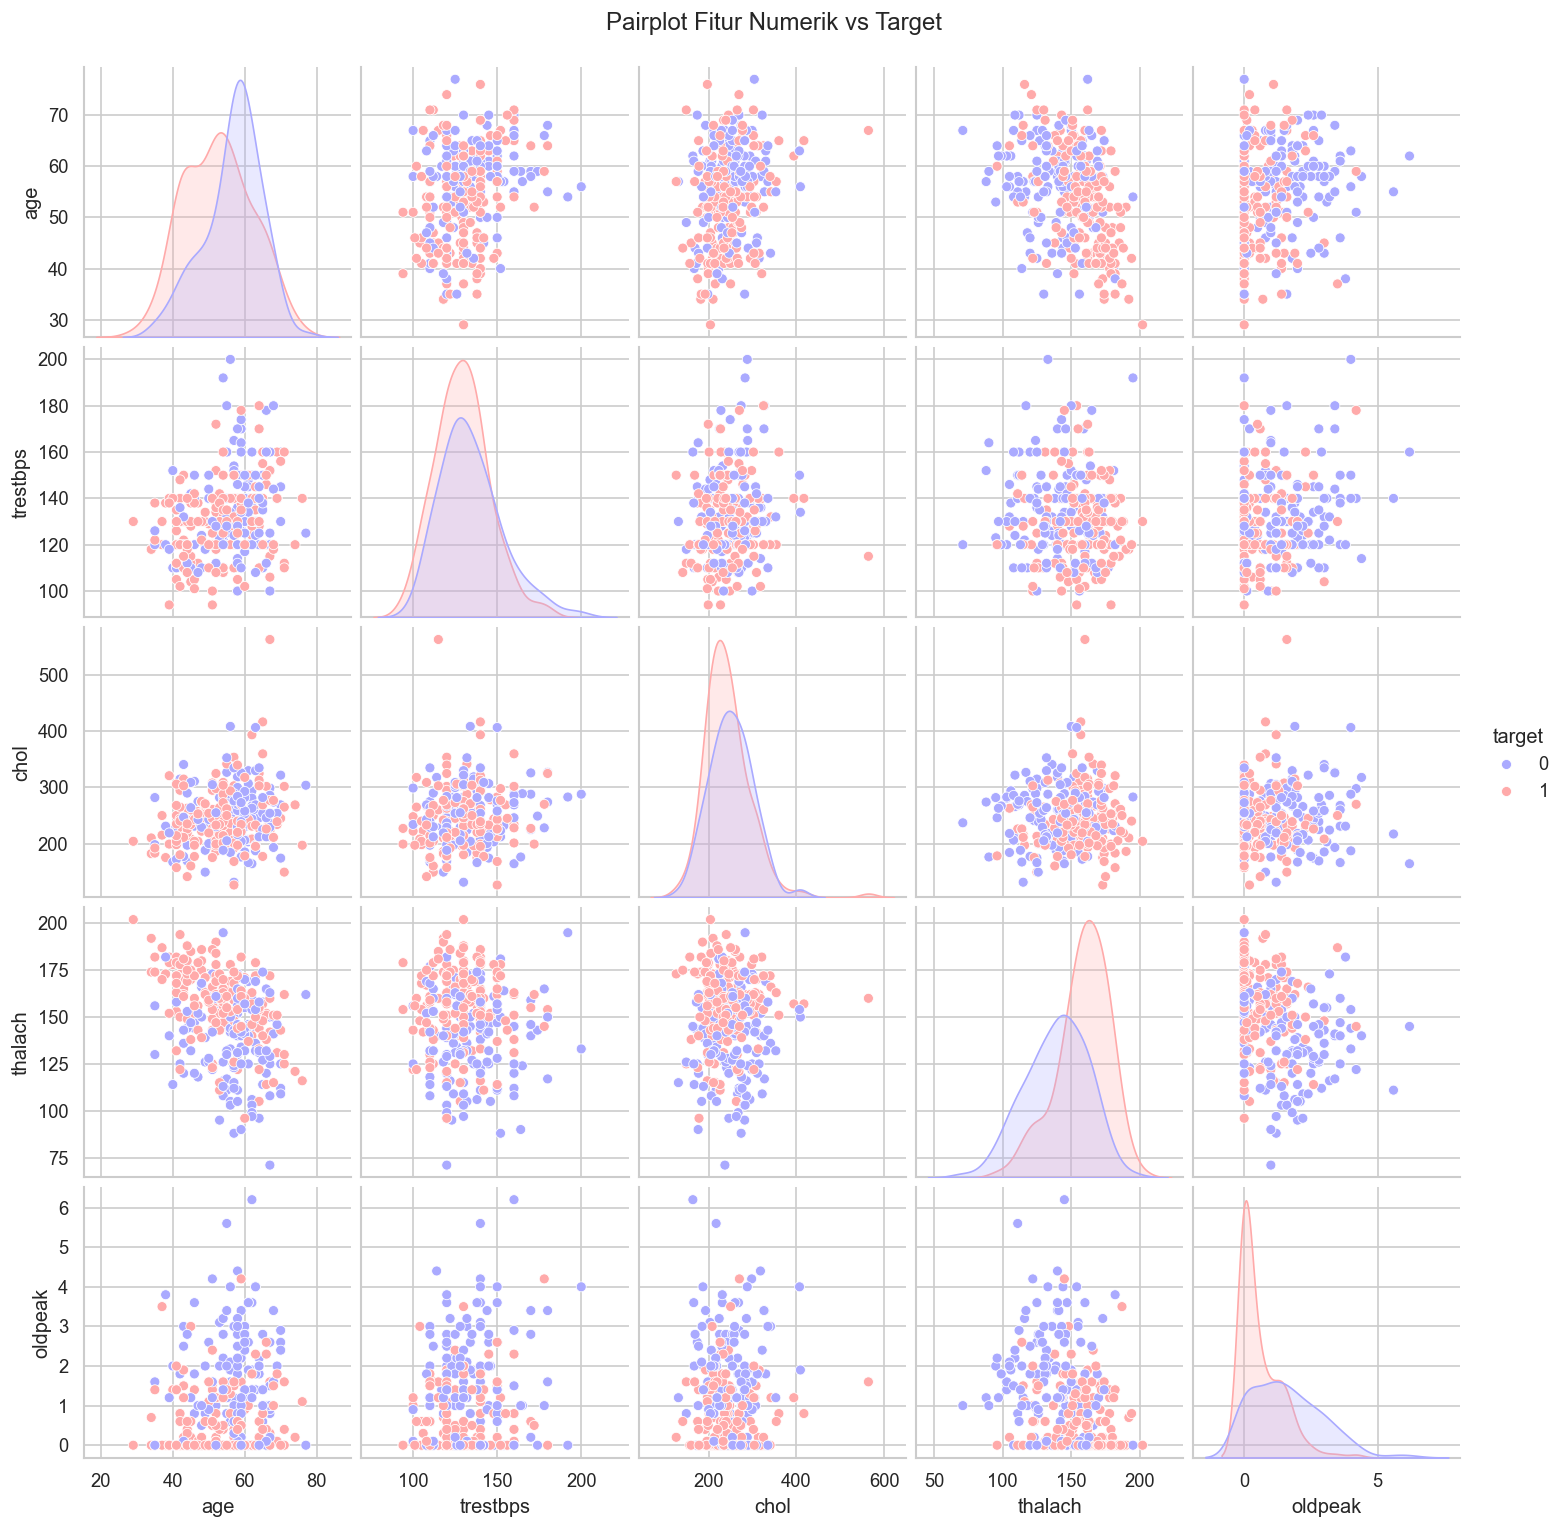

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="age", y="thalach", hue="target", style="cp", palette="bwr", alpha=0.8, s=70)
plt.title("Interaksi Usia, Thalach, dan cp terhadap Target")
plt.xlabel("Usia")
plt.ylabel("thalach")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("fig_scatter_age_thalach.png", dpi=300)
plt.show()

selected = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]
sns.pairplot(df[selected], hue="target", palette="bwr", diag_kind="kde")
plt.suptitle("Pairplot Fitur Numerik vs Target", y=1.02)
plt.savefig("fig_pairplot.png", dpi=300)
plt.show()

## 9. Ringkasan Insight

1. **Kualitas data:** 0 missing, tetapi **723/1025 (70,5%) duplikat** — hanya 302 baris unik. Wajib deduplikasi sebelum modeling; jika tidak, akurasi akan semu (data leakage via duplikat di train/test).
2. **Target seimbang:** sakit 164 (54,3%) vs sehat 138 (45,7%) — tidak perlu balancing khusus.
3. **Fitur paling prediktif (|r|):** `cp` (0,43) > `thalach` (0,42) > `exang`/`oldpeak` (~0,43 negatif) > `ca` (0,41) > `thal` (0,34) > `slope` (0,34). `chol`, `fbs`, `restecg`, `trestbps` lemah (|r| < 0,15).
4. **Nyeri dada (cp) paling diskriminatif:** cp=0 → 72,7% sehat; cp=1/2/3 → 82,0% / 79,1% / 69,6% sakit.
5. **Paradoks klinis — bahan diskusi:** `exang`=1 justru 76,8% sehat; `oldpeak` tinggi & `thalach` rendah justru di kelompok sehat; pasien sakit lebih muda (52,4 vs 56,6 th) dengan thalach lebih tinggi (158,6 vs 139,1). Berlawanan dengan literatur — indikasi label terbalik / artefak penggabungan dataset. Jangan diklaim sebagai fakta medis.
6. **Efek jenis kelamin:** wanita 75,0% sakit vs pria 44,7% sakit — kemungkinan bias sampling (hanya 96 wanita vs 206 pria), bukan kesimpulan populasi.
7. **Skew & outlier ringan:** `chol` (skew 1,15) & `oldpeak` (1,27) menjulur kanan; outlier IQR <3% (trestbps 2,9% tertinggi) — aman, cukup dengan scaling/transformasi saat modeling.
8. **Multikolinearitas rendah:** korelasi antar-fitur tertinggi hanya `oldpeak–slope` (−0,58); sisanya |r| < 0,45 — semua fitur utama bisa dipakai bersama.

## 10. Kesimpulan & Rekomendasi

- Dataset layak dimodelkan **setelah deduplikasi (n=302)**; laporkan kedua angka (mentah vs bersih) di makalah.
- Fitur prioritas untuk model/ablasi: `cp, thalach, exang, oldpeak, ca, thal, slope`.
- Langkah lanjut: stratified split / cross-validation pada data bersih, scaling untuk `chol/oldpeak/trestbps`, encoding kategorik, dan uji model baseline (logistic regression / tree).
- Cantumkan keterbatasan: duplikasi masif, anomali arah korelasi klinis, sampel wanita kecil, dan nilai `thal=0` / `ca=4` yang jarang (kemungkinan kode missing).